# 🔬 Advanced Simulator: Sensitometry and Optical Physics

### Welcome, Material Scientists!
At the university level, we analyze film not as a magical canvas, but as a quantifiable data-storage medium constrained by the laws of quantum mechanics and optics.

In this notebook, we will simulate two critical physical models:
1. **The H&D Curve (Sensitometry):** Modeling how silver halide crystals respond to logarithmic increases in photon exposure.
2. **Diffraction Limits (Optics):** Calculating the point where the wave nature of light physically degrades image resolution, overriding the quality of the lens.

**Professor Instructions:** Run the cells below to generate the characteristic curve of a synthetic film and calculate optical limits.

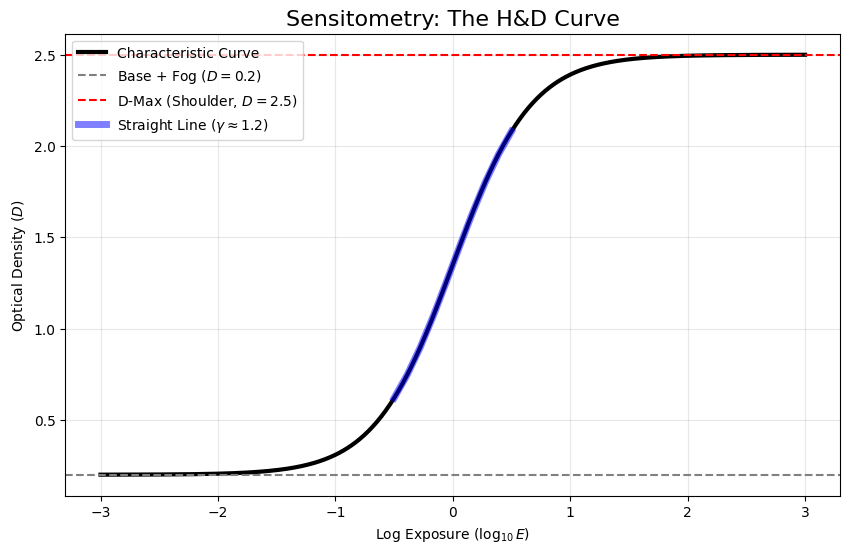

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_characteristic_curve():
    """
    Simulates the Hurter & Driffield (H&D) Characteristic Curve of a photographic film.
    Uses a logistic (sigmoid) function to model the Toe, Straight Line, and Shoulder.
    """
    # Generate Log Exposure (Log E) values from -3.0 to 3.0
    log_E = np.linspace(-3.0, 3.0, 500)
    
    # Film Parameters
    base_plus_fog = 0.2    # Inherent density of the plastic base and unexposed silver
    d_max = 2.5            # Maximum possible density (The Shoulder)
    gamma = 1.2            # Slope of the straight line (Contrast)
    speed_point = 0.0      # The center point of the exposure curve
    
    # Logistic function to simulate the S-Curve of film density
    density = base_plus_fog + (d_max - base_plus_fog) / (1 + np.exp(-gamma * (log_E - speed_point) * 2.5))
    
    plt.figure(figsize=(10, 6))
    plt.plot(log_E, density, 'k-', linewidth=3, label="Characteristic Curve")
    
    # Annotate the specific regions of the curve
    plt.axhline(base_plus_fog, color='gray', linestyle='--', label=f"Base + Fog ($D = {base_plus_fog}$)")
    plt.axhline(d_max, color='red', linestyle='--', label=f"D-Max (Shoulder, $D = {d_max}$)")
    
    # Highlight the Straight Line portion (Gamma)
    straight_line_x = np.linspace(-0.5, 0.5, 10)
    straight_line_y = base_plus_fog + (d_max - base_plus_fog) / (1 + np.exp(-gamma * (straight_line_x - speed_point) * 2.5))
    plt.plot(straight_line_x, straight_line_y, 'b-', linewidth=5, alpha=0.5, label=f"Straight Line ($\\gamma \\approx {gamma}$)")

    plt.title("Sensitometry: The H&D Curve", fontsize=16)
    plt.xlabel("Log Exposure ($\\log_{10} E$)")
    plt.ylabel("Optical Density ($D$)")
    plt.grid(True, alpha=0.3)
    plt.legend(loc="upper left")
    plt.show()

# Run the Sensitometry Simulator!
plot_characteristic_curve()

### 📊 Analysis of the H&D Curve
The graph above is the fingerprint of our synthetic film. 

* **The Toe (Left):** Photons are hitting the film, but they haven't reached the quantum threshold necessary to build a stable latent image. The density barely rises above the Base+Fog level.
* **The Straight Line (Center):** This is the usable dynamic range of the film. For every proportional increase in $\log_{10} E$, there is a predictable, linear increase in Optical Density ($D$). 
* **The Shoulder (Right):** The film is chemically exhausted. Almost all $AgBr$ crystals have been reduced. Pumping more light onto the film will not yield more detail; the highlights are permanently "blown out."

---

### 🌊 The Wave Nature of Light: Diffraction
Even if your film has a perfect H&D curve, the laws of physics might ruin your image before the light even hits the emulsion.

Because light travels as a wave, it diffracts (bends and spreads) when it passes through the small opening of your aperture. This spreading creates an **Airy Disk**. If the Airy Disks of two adjacent points overlap too much, the lens can no longer resolve them as separate points.

We calculate the size of this diffraction blur using the Rayleigh Criterion approximation:
$$x \approx 1.22 \cdot \lambda \cdot N$$

Where:
* $x$ = Diameter of the Airy disk (blur spot)
* $\lambda$ = Wavelength of the light (e.g., $550$ nm for green light)
* $N$ = Aperture f-number

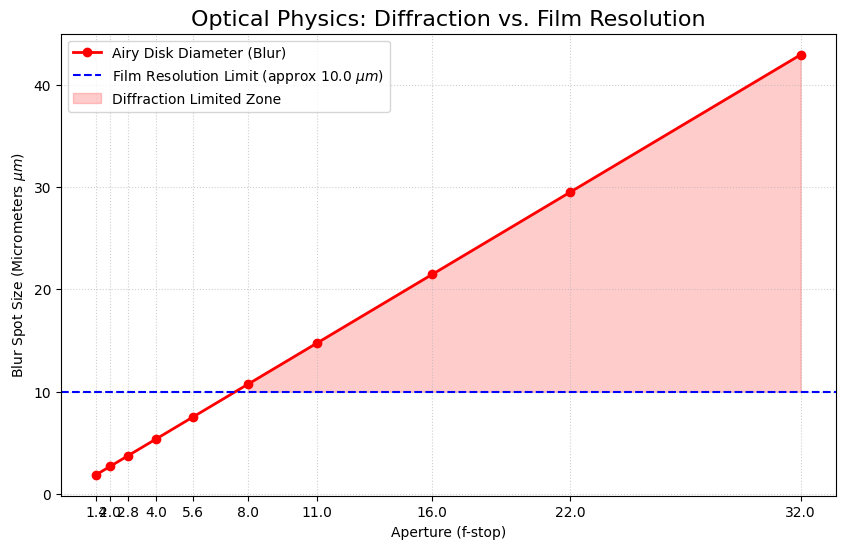

In [2]:
def plot_diffraction_limits():
    """
    Calculates and plots the size of the Airy disk caused by diffraction
    at various aperture settings, comparing it to a high-resolution film's grain size.
    """
    f_stops = np.array([1.4, 2.0, 2.8, 4.0, 5.6, 8.0, 11.0, 16.0, 22.0, 32.0])
    
    # Wavelength of green light (~550 nanometers, converted to micrometers)
    wavelength_um = 0.55 
    
    # Calculate Airy Disk diameter in micrometers (um)
    # Formula: 1.22 * wavelength * f-number * 2 (for full diameter)
    airy_disk_diameter_um = 2.44 * wavelength_um * f_stops
    
    plt.figure(figsize=(10, 6))
    plt.plot(f_stops, airy_disk_diameter_um, 'ro-', linewidth=2, label="Airy Disk Diameter (Blur)")
    
    # Let's assume a highly engineered, fine-grain film (like Kodak T-Max 100) 
    # has a resolving power where grain clumps act like a ~10 micrometer pixel.
    film_resolution_limit = 10.0 
    plt.axhline(film_resolution_limit, color='b', linestyle='--', 
                label=f"Film Resolution Limit (approx {film_resolution_limit} $\\mu m$)")
    
    # Shade the "Diffraction Limited" zone
    plt.fill_between(f_stops, airy_disk_diameter_um, film_resolution_limit, 
                     where=(airy_disk_diameter_um > film_resolution_limit), 
                     color='red', alpha=0.2, label="Diffraction Limited Zone")

    plt.title("Optical Physics: Diffraction vs. Film Resolution", fontsize=16)
    plt.xlabel("Aperture (f-stop)")
    plt.ylabel("Blur Spot Size (Micrometers $\\mu m$)")
    plt.xticks(f_stops)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()

# Run the Diffraction Simulator!
plot_diffraction_limits()

### 🔬 The Engineering Trade-off
Look at the intersection on the diffraction graph. 

When you "stop down" a lens (moving toward f/16, f/22, or f/32), you increase your Depth of Field geometrically. However, you simultaneously increase the diffraction blur physically! 

Once the red line crosses the blue dotted line (around f/8 to f/11 in this simulation), the image begins to get *softer* because the wave interference of the light (the Airy disk) is now physically larger than the grain structure of the film itself. This is known as becoming **Diffraction Limited**. 

Mastery of the medium requires balancing the Sensitometry of the chemistry with the Quantum optical limits of the lens.